In [1]:
from qutip import*
import numpy as np
import matplotlib.pyplot as plt
import krotov as kt

In [ ]:
#Definimos la base computacional y creamos los estados iniciales
ket_0 = basis(2,0)
ket_1 = basis(2,1)

ket_00 = tensor(ket_0,ket_0)
ket_01 = tensor(ket_0,ket_1)
ket_10 = tensor(ket_1,ket_0)
ket_11 = tensor(ket_1,ket_1)
ket_arb=1/np.sqrt(2)*(ket_00 + ket_10)
ket_arb2=1/np.sqrt(2)*(ket_01 - ket_10)
ket_arb3=1/np.sqrt(2)*(ket_00 + 1j*ket_11)
ket_ale=Qobj(np.array([[-0.255+0.713j],[-0.128+0.002j],[0.618+0.130j],[0.016+0.106j]]), dims=[[2,2],[1,1]])

#Producto tensorial para matrices de pauli
sig_z1 = tensor(sigmaz(), qeye(2))
sig_z2 = tensor(qeye(2), sigmaz())
sig_x1 = tensor(sigmax(), qeye(2)) 
sig_x2 = tensor(qeye(2), sigmax())
sig_y1 = tensor(sigmay(), qeye(2)) 
sig_y2 = tensor(qeye(2), sigmay())
sig_xx = tensor(sigmax(), sigmax())
sig_yy = tensor(sigmay(), sigmay())
sig_zz = tensor(sigmaz(), sigmaz())
sig_mm = tensor(sigmam(), sigmam())

In [3]:
#Matrices densidad
psi_00_00 = ket2dm(ket_00)
psi_01_01 = ket2dm(ket_01)
psi_10_10 = ket2dm(ket_10)
psi_11_11 = ket2dm(ket_11)
psi_arb=ket_arb*ket_arb.dag()
psi_arb2=ket_arb2*ket_arb2.dag()
psi_arb3=ket_arb3*ket_arb3.dag()

#compuerta cnot
CNOT = tensor(ket2dm(basis(2,0)), qeye(2)) + tensor(ket2dm(basis(2,1)), sigmax())

#Estado al aplicar CNOT
psi_cnot_00=CNOT*psi_00_00*CNOT.dag()
psi_cnot_01=CNOT*psi_01_01*CNOT.dag()
psi_cnot_10=CNOT*psi_10_10*CNOT.dag()
psi_cnot_11=CNOT*psi_11_11*CNOT.dag()
psi_cnot_arb=CNOT*psi_arb*CNOT.dag()
psi_cnot_arb2=CNOT*psi_arb2*CNOT.dag()
psi_cnot_arb3=CNOT*psi_arb3*CNOT.dag()

#coherencias
psi_01_00 = ket_01*ket_00.dag()
psi_01_11 = ket_01*ket_11.dag()
psi_01_10 = ket_01*ket_10.dag()

psi_10_01 = ket_10*ket_01.dag()
psi_10_00 = ket_10*ket_00.dag()
psi_10_11 = ket_10*ket_11.dag()

psi_11_01 = ket_11*ket_01.dag()
psi_11_00 = ket_11*ket_00.dag()
psi_11_10 = ket_11*ket_10.dag()

psi_00_10 = ket_00*ket_10.dag()
psi_00_11 = ket_00*ket_11.dag()

# **Ejemplo para la compuerta CNOT usando 6 controles y un acople transversal $$\sigma_x\otimes\sigma_x$$**

In [ ]:
#Definimos las 6 funciones de control iniciales para la CNOT (Se definen los mismos parametros que se utilizan para Hadamard)
def guess_control_x1 (t, _=None):
    A= 1e-2    #Amplitud del modelo de control cuantico
    return A*np.vectorize(kt.shapes.flattop)(t, t_start =times[0], t_stop =times[-1], t_rise =times[-1]/30, func = "sinsq")

def guess_control_x2 (t, _=None):
    A= 1e-2    #Amplitud del modelo de control cuantico
    return A*np.vectorize(kt.shapes.flattop)(t, t_start =times[0], t_stop =times[-1], t_rise =times[-1]/30, func = "sinsq")

def guess_control_y1 (t, _=None):
    A= 1e-2    #Amplitud del modelo de control cuantico
    return A*np.vectorize(kt.shapes.flattop)(t, t_start =times[0], t_stop =times[-1], t_rise =times[-1]/30, func = "sinsq")

def guess_control_y2 (t, _=None):
    A= 1e-2    #Amplitud del modelo de control cuantico
    return A*np.vectorize(kt.shapes.flattop)(t, t_start =times[0], t_stop =times[-1], t_rise =times[-1]/30, func = "sinsq")

def guess_control_z1 (t, _=None):
    A= 1e-2    #Amplitud del modelo de control cuantico
    return A*np.vectorize(kt.shapes.flattop)(t, t_start =times[0], t_stop =times[-1], t_rise =times[-1]/30, func = "sinsq")

def guess_control_z2 (t, _=None):
    A= 1e-2    #Amplitud del modelo de control cuantico
    return A*np.vectorize(kt.shapes.flattop)(t, t_start =times[0], t_stop =times[-1], t_rise =times[-1]/30, func = "sinsq")

# Tiempo de la evolucion del sistema
times=np.linspace(0.0,5.0,500)

#Definimos el hamiltoniano del sistema
H0 = sig_xx
H_x1=sig_x1
H_x2 = sig_x2
H_y1= sig_y1
H_y2 = sig_y2
H_z1 = sig_z1
H_z2 = sig_z2
H=[H0, [H_x1,guess_control_x1], [H_x2,guess_control_x2], [H_y1,guess_control_y1], [H_y2,guess_control_y2], [H_z1,guess_control_z1], [H_z2,guess_control_z2]]

#Definimos el hamiltoniano con forma de liouvillian (necesario si queremos ejecutar tareas cuanticas en forma de matrice densidad)
H_L=kt.objectives.liouvillian(H, c_ops=[])


In [ ]:
#Establecemos la tarea cuantica para el control cuantico con 7 estados iniciales (transfer_state)
task=[kt.Objective(initial_state=psi_00_00, target=psi_cnot_00, H=H_L), 
        kt.Objective(initial_state=psi_01_01, target=psi_cnot_01, H=H_L), 
        kt.Objective(initial_state=psi_10_10, target=psi_cnot_10, H=H_L), 
        kt.Objective(initial_state=psi_11_11, target=psi_cnot_11, H=H_L), 
        kt.Objective(initial_state=psi_arb, target=psi_cnot_arb, H=H_L),
        kt.Objective(initial_state=psi_arb2, target=psi_cnot_arb2, H=H_L),
        kt.Objective(initial_state=psi_arb3, target=psi_cnot_arb3, H=H_L)]

#Objetivo como compuerta (Esta es la forma de Krotov para definir compuertas cuanticas como tareas cuanticas)
#La desventaja de usar este metodo, es que en su forma original solo admite la base computacional en la dimension de la compuerta
# y otros conjuntos de estados en particular. Para usar otros estados y darles pesos (w), se nesecita modificar el metodo.
task_gate=kt.gate_objectives(basis_states=[ket_00,ket_01,ket_10,ket_11], gate=CNOT, H=H_L)

In [6]:
#Definimos ahora la funcion S(t) para la fase de actualizacion del control
def S(t):
  return np.vectorize(kt.shapes.flattop)(t , t_start =times[0] , t_stop =times[-1] , t_rise =times[-1]/30 , func = "sinsq")

#Parámetros de Krotov
pulse_options= {guess_control_x1: dict(lambda_a=1, update_shape=S), 
                guess_control_x2: dict(lambda_a=1, update_shape=S),
                guess_control_y1: dict(lambda_a=1, update_shape=S),
                guess_control_y2: dict(lambda_a=1, update_shape=S),
                guess_control_z1: dict(lambda_a=1, update_shape=S),
                guess_control_z2: dict(lambda_a=1, update_shape=S)}


In [7]:
    # Ejecutar la optimización
optimized_result = kt.optimize_pulses(
        task,
        pulse_options= pulse_options,
        tlist=times,
        #propagator=kt.propagators.DensityMatrixODEPropagator(reentrant=True),  
        propagator=kt.propagators.expm, # Método de propagación (exponencial matricial)
        chi_constructor=kt.functionals.chis_re,  # Condición adjunta (final time)
        #iter_stop=20,  # Número de iteraciones
        info_hook=kt.info_hooks.print_table(J_T=kt.functionals.J_T_re),  # Mostrar progreso, providing J_T explicitly
        check_convergence = kt.convergence.Or(
        kt.convergence.value_below ('1e-3', name ='J_T') ,
        kt.convergence.check_monotonic_error,), store_all_pulses = True,)


iter.      J_T   ∑∫gₐ(t)dt          J       ΔJ_T         ΔJ  secs
0     8.89e-01    0.00e+00   8.89e-01        n/a        n/a    15
1     8.26e-01    3.17e-02   8.58e-01  -6.34e-02  -3.17e-02    39
2     6.68e-01    7.92e-02   7.47e-01  -1.58e-01  -7.92e-02    39
3     3.62e-01    1.53e-01   5.15e-01  -3.06e-01  -1.53e-01    39
4     2.38e-01    6.20e-02   3.00e-01  -1.24e-01  -6.20e-02    39
5     2.08e-01    1.49e-02   2.23e-01  -2.97e-02  -1.49e-02    43
6     1.92e-01    8.15e-03   2.00e-01  -1.63e-02  -8.15e-03    44
7     1.77e-01    7.29e-03   1.84e-01  -1.46e-02  -7.30e-03    49
8     1.63e-01    7.23e-03   1.70e-01  -1.45e-02  -7.24e-03    46
9     1.48e-01    7.16e-03   1.55e-01  -1.43e-02  -7.17e-03    45
10    1.34e-01    6.98e-03   1.41e-01  -1.40e-02  -6.98e-03    47
11    1.21e-01    6.80e-03   1.27e-01  -1.36e-02  -6.80e-03    42
12    1.07e-01    6.76e-03   1.14e-01  -1.35e-02  -6.76e-03    42
13    9.35e-02    6.82e-03   1.00e-01  -1.36e-02  -6.82e-03    64
14    7.98

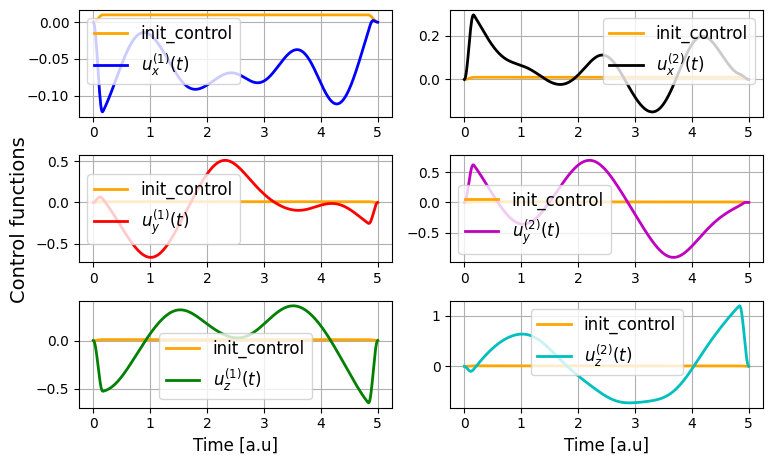

In [9]:
# Campos de control optimizados
optimized_pulse_x1 = optimized_result.optimized_controls[0]
optimized_pulse_x2 = optimized_result.optimized_controls[1]
optimized_pulse_y1 = optimized_result.optimized_controls[2]
optimized_pulse_y2 = optimized_result.optimized_controls[3]
optimized_pulse_z1 = optimized_result.optimized_controls[4]
optimized_pulse_z2 = optimized_result.optimized_controls[5]

fig, ax =plt.subplots(3,2, figsize=(8,5))

ax[0,0].plot(times, guess_control_x1(times), 'orange', linestyle='solid', linewidth=2, label=f'init_control')
ax[0,0].plot(times, optimized_pulse_x1, 'b', linestyle='solid', linewidth=2, label=r'$u_{x}^{(1)}(t)$')
ax[0,0].legend(fontsize=12)
ax[0,0].grid()

ax[0,1].plot(times, guess_control_x2(times), 'orange', linestyle='solid', linewidth=2, label=f'init_control')
ax[0,1].plot(times, optimized_pulse_x2, 'k', linestyle='solid', linewidth=2, label=r'$u_{x}^{(2)}(t)$')
ax[0,1].legend(fontsize=12)
ax[0,1].grid()

ax[1,0].plot(times, guess_control_y1(times), 'orange', linestyle='solid', linewidth=2, label=f'init_control')
ax[1,0].plot(times, optimized_pulse_y1, 'r', linestyle='solid', linewidth=2, label=r'$u_{y}^{(1)}(t)$')
ax[1,0].legend(fontsize=12)
ax[1,0].grid()

ax[1,1].plot(times, guess_control_y2(times), 'orange', linestyle='solid', linewidth=2, label=f'init_control')
ax[1,1].plot(times, optimized_pulse_y2, 'm', linestyle='solid', linewidth=2, label=r'$u_{y}^{(2)}(t)$')
ax[1,1].legend(fontsize=12)
ax[1,1].grid()

ax[2,0].plot(times, guess_control_z1(times), 'orange', linestyle='solid', linewidth=2, label=f'init_control')
ax[2,0].plot(times, optimized_pulse_z1, 'g', linestyle='solid', linewidth=2, label=r'$u_{z}^{(1)}(t)$')
ax[2,0].legend(fontsize=12)
ax[2,0].set_xlabel('Time [a.u]', fontsize=12)
ax[2,0].grid()

ax[2,1].plot(times, guess_control_z2(times), 'orange', linestyle='solid', linewidth=2, label=f'init_control')
ax[2,1].plot(times, optimized_pulse_z2, 'c', linestyle='solid', linewidth=2, label=r'$u_{z}^{(2)}(t)$')
ax[2,1].set_xlabel('Time [a.u]', fontsize=12)
ax[2,1].legend(fontsize=12)
ax[2,1].grid()

fig.supylabel('Control functions', fontsize=14, x=0.04)
plt.tight_layout(rect=[0, 0, 1, 0.95])

#plt.savefig("Control_HxH_z.png", dpi=300)
plt.show()

# **Fidelidad promedio (500 estados aleatorios)**

In [13]:
#Definimos el Hamiltoniano nuevamente, controlado por las funciones actualizadas
H2=[H0, [H_x1,optimized_pulse_x1], [H_x2,optimized_pulse_x2], [H_y1,optimized_pulse_y1], [H_y2,optimized_pulse_y2], [H_z1,optimized_pulse_z1], [H_z2,optimized_pulse_z2]]

In [11]:
#Estados puros aleatorios
total_estados = 500
qubit_1 = [rand_ket(2) for i in range(total_estados)] # Genero total_estados kets aleatorios para qubit 1
qubit_2 = [rand_ket(2) for i in range(total_estados)] # Genero total_estados kets aleatorios para qubit 2
qubits_12 = [tensor(kets_q1, kets_q2) for kets_q1, kets_q2 in zip(qubit_1, qubit_2)] # Producto tensorial de los qubits

In [12]:
# Aplico la CNOT y calculo los estados iniciales en representación de matrices
CNOT_rho=[]
rho0=[]
for ket in qubits_12:
    rho=ket*ket.dag()
    rho0.append(rho)
    CNOT_rho.append(CNOT*rho*CNOT.dag())

In [14]:
DC_H2=[]
for rho in rho0:
    solution=mesolve(H2, rho, times, [], [])
    DC_H2.append(solution.states[-1])

In [22]:
DC_f_H2=[]
for N in range(total_estados):
    fid=fidelity(DC_H2[N], CNOT_rho[N])
    DC_f_H2.append(fid**2)
DC_prome_H2=sum(DC_f_H2)/total_estados

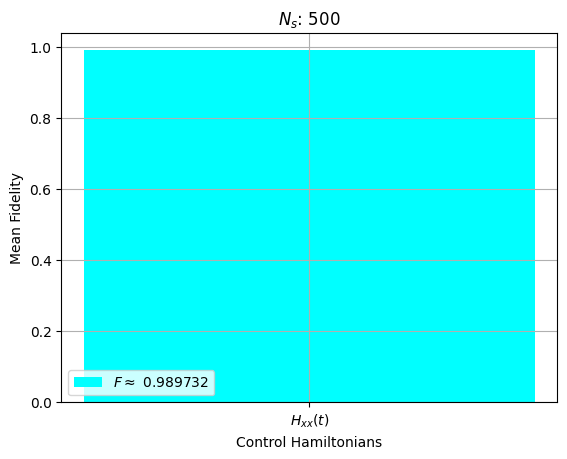

In [28]:
#Fidelidad promedio como diagrama de barras
# Posicion para la barra
x = 0

plt.bar(x, DC_prome_H2, color='cyan', label=f"$F\\approx$ {DC_prome_H2:.6f}")

plt.title(f"$N_s$: {total_estados}")
plt.xlabel('Control Hamiltonians')
plt.ylabel('Mean Fidelity')
plt.xticks([x], [r"$H_{xx}(t)$"])
plt.legend(loc='lower left')
plt.grid(True)
plt.show()
